# XGBoost Regression with a `log1p` Target

The model is trained on `np.log1p(charges)`. Predictions are converted back to the original scale with `np.expm1`, and all main metrics (RMSE, MAE, R2) are reported on that original `charges` scale.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data_df = pd.read_csv("data_cleaned.csv")
print(f"Loaded {len(data_df)} rows, {len(data_df.columns)} columns")
print(f"Columns: {list(data_df.columns)}")
data_df.head()

Loaded 1337 rows, 9 columns
Columns: ['age', 'bmi', 'children', 'charges', 'gender_encoded', 'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,gender_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,1,0.0,0.0,1.0
1,18,33.770,1,1725.55230,0,0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,0,0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,0,0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,0,0,1.0,0.0,0.0


## 1. Train/Test Split and Target Transform

After splitting the data, we transform the training target using `np.log1p` for XGBoost training (`y_train_log`).

In [ ]:
from sklearn.model_selection import train_test_split

raw_feature_cols = [
    'age', 'bmi', 'children', 'gender_encoded', 'smoker_encoded',
    'region_northwest', 'region_southeast', 'region_southwest'
]

# Split first, then engineer features separately to keep evaluation setup clean.
X_raw = data_df[raw_feature_cols]
y = data_df['charges']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

def add_features(df):
    out = df.copy()
    out['age_squared'] = out['age'] ** 2
    out['smoker_bmi'] = out['smoker_encoded'] * out['bmi']
    return out

X_train = add_features(X_train_raw)
X_test = add_features(X_test_raw)

feature_cols = [
    'age', 'age_squared', 'bmi', 'children', 'gender_encoded', 'smoker_encoded',
    'region_northwest', 'region_southeast', 'region_southwest', 'smoker_bmi'
]

X_train = X_train[feature_cols]
X_test = X_test[feature_cols]
y_train_log = np.log1p(y_train)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print("Target for fitting: y_train_log = np.log1p(y_train); inverse at predict: np.expm1")

Training set: 1069 samples
Test set:     268 samples
Target for fitting: y_train_log = np.log1p(y_train); inverse at predict: np.expm1


## 2. Model Training (Tuned, Log-Target)

`RandomizedSearchCV` and early stopping use RMSE on **`log1p(charges)`**. Final predictions are then converted with `expm1` so evaluation is easy to interpret in the original dollar scale.

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# Baseline: fit on log1p(charges); predictions back to original scale
baseline_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    objective='reg:squarederror',
    eval_metric='rmse',
)
baseline_model.fit(X_train, y_train_log)
y_pred_train_baseline = np.expm1(baseline_model.predict(X_train))
y_pred_test_baseline = np.expm1(baseline_model.predict(X_test))

# Hold-out validation for early stopping is created from training data only.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_log, test_size=0.2, random_state=42
)

base_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
)

param_dist = {
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05, 0.08],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0.0, 0.1, 0.5, 1.0],
    'reg_lambda': [1.0, 2.0, 5.0, 10.0],
    'n_estimators': [300, 500, 800],
}

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=0,
)
search.fit(X_tr, y_tr)

tuned_params = search.best_params_.copy()

monitoring_model = XGBRegressor(
    **tuned_params,
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
    early_stopping_rounds=50,
)
monitoring_model.fit(
    X_tr,
    y_tr,
    # eval_set=[(X_val, y_val)],
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False,
)

evals_result = monitoring_model.evals_result()
tuned_n_estimators = int(monitoring_model.best_iteration + 1)

# Use 25% extra trees as a buffer when refitting on full training data.
final_n_estimators = int(tuned_n_estimators * 1.25)

model = XGBRegressor(
    **{k: v for k, v in tuned_params.items() if k != 'n_estimators'},
    n_estimators=final_n_estimators,
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
)
model.fit(X_train, y_train_log)

y_pred_train = np.expm1(model.predict(X_train))
y_pred_test = np.expm1(model.predict(X_test))

print('XGBoost tuning completed (target: log1p(charges)).')
print('Metrics in the next section use original scale (expm1).')
print('Best params:', tuned_params)
print(f'Best boosting rounds from early stopping: {tuned_n_estimators}')
print(f'monitoring best_iteration: {tuned_n_estimators}  ->  final n_estimators: {final_n_estimators}')

XGBoost tuning completed (target: log1p(charges)).
Metrics in the next section use original scale (expm1).
Best params: {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best boosting rounds from early stopping: 500
monitoring best_iteration: 500  ->  final n_estimators: 625


## 3. Model Evaluation (R2, RMSE, MAE on Original `charges`)

Here, original `y_train` and `y_test` are compared against predictions after applying `expm1`.

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np


def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100


def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true) + np.abs(y_pred), eps)
    return np.mean(2.0 * np.abs(y_true - y_pred) / denom) * 100


# Tuned model metrics (original dollar scale)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
mape_train = mape(y_train, y_pred_train)
mape_test = mape(y_test, y_pred_test)
smape_train = smape(y_train, y_pred_train)
smape_test = smape(y_test, y_pred_test)

# Baseline metrics (before tuning)
r2_train_base = r2_score(y_train, y_pred_train_baseline)
r2_test_base = r2_score(y_test, y_pred_test_baseline)
rmse_train_base = np.sqrt(mean_squared_error(y_train, y_pred_train_baseline))
rmse_test_base = np.sqrt(mean_squared_error(y_test, y_pred_test_baseline))
mae_train_base = mean_absolute_error(y_train, y_pred_train_baseline)
mae_test_base = mean_absolute_error(y_test, y_pred_test_baseline)
mape_train_base = mape(y_train, y_pred_train_baseline)
mape_test_base = mape(y_test, y_pred_test_baseline)
smape_train_base = smape(y_train, y_pred_train_baseline)
smape_test_base = smape(y_test, y_pred_test_baseline)

metrics = pd.DataFrame({
    'Metric': ['R2', 'RMSE', 'MAE', 'MAPE (%)', 'sMAPE (%)'],
    'Train': [r2_train, rmse_train, mae_train, mape_train, smape_train],
    'Test': [r2_test, rmse_test, mae_test, mape_test, smape_test]
})

comparison_before_after = pd.DataFrame([
    {
        'Model': 'Baseline',
        'R2_train': r2_train_base,
        'R2_test': r2_test_base,
        'RMSE_train': rmse_train_base,
        'RMSE_test': rmse_test_base,
        'MAE_train': mae_train_base,
        'MAE_test': mae_test_base,
        'MAPE_train': mape_train_base,
        'MAPE_test': mape_test_base,
        'sMAPE_train': smape_train_base,
        'sMAPE_test': smape_test_base,
    },
    {
        'Model': 'Tuned',
        'R2_train': r2_train,
        'R2_test': r2_test,
        'RMSE_train': rmse_train,
        'RMSE_test': rmse_test,
        'MAE_train': mae_train,
        'MAE_test': mae_test,
        'MAPE_train': mape_train,
        'MAPE_test': mape_test,
        'sMAPE_train': smape_train,
        'sMAPE_test': smape_test,
    }
])

print('Model performance (original charges; y vs expm1 predictions):\n')
print(metrics.to_string(index=False, formatters={
    'Train': lambda x: f'{x:,.4f}' if x < 100 else f'{x:,.0f}',
    'Test': lambda x: f'{x:,.4f}' if x < 100 else f'{x:,.0f}',
}))

print('\nBefore vs After Tuning:\n')
display(comparison_before_after.style.format({
    'R2_train': '{:.4f}', 'R2_test': '{:.4f}',
    'RMSE_train': '{:,.0f}', 'RMSE_test': '{:,.0f}',
    'MAE_train': '{:,.0f}', 'MAE_test': '{:,.0f}',
    'MAPE_train': '{:.2f}%', 'MAPE_test': '{:.2f}%',
    'sMAPE_train': '{:.2f}%', 'sMAPE_test': '{:.2f}%'
}))

Model performance (original charges; y vs expm1 predictions):

   Metric   Train    Test
       R2  0.8641  0.8972
     RMSE   4,314   4,347
      MAE   1,871   2,015
 MAPE (%) 15.2142 16.3005
sMAPE (%) 16.7199 17.3060

Before vs After Tuning:



,Model,R2_train,R2_test,RMSE_train,RMSE_test,MAE_train,MAE_test,MAPE_train,MAPE_test,sMAPE_train,sMAPE_test
0,Baseline,0.9257,0.7575,"3,189","6,675","1,461","2,824",10.56%,23.00%,11.11%,20.61%
1,Tuned,0.8641,0.8972,"4,314","4,347","1,871","2,015",15.21%,16.30%,16.72%,17.31%


## 3b. Cross-Validation (5-Fold, Metrics on Original Scale)

`TransformedTargetRegressor` handles the `log1p`/`expm1` mapping, so RMSE/MAE/R2 scores stay comparable with Section 3.

In [ ]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import TransformedTargetRegressor
from xgboost import XGBRegressor
import pandas as pd

if 'tuned_params' not in globals():
    raise RuntimeError("`tuned_params` is not found. Run the tuning cell first.")

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_xgb_params = {
    **tuned_params,
    'random_state': 42,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
}
cv_model = TransformedTargetRegressor(
    regressor=XGBRegressor(**cv_xgb_params),
    func=np.log1p,
    inverse_func=np.expm1,
)

# CV is run on training split only, so test set remains untouched.
cv_scores = cross_validate(
    cv_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'  # optional overview metric
    },
    return_train_score=False,
    n_jobs=1
)

n_folds = cv.get_n_splits()
cv_result = pd.DataFrame({
    'Fold': [f'Fold {i}' for i in range(1, n_folds + 1)],
    'RMSE': -cv_scores['test_rmse'],
    'MAE': -cv_scores['test_mae'],
    'R2 (optional)': cv_scores['test_r2']
})

cv_summary = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R2 (optional)'],
    'Mean (5-Fold CV)': [
        cv_result['RMSE'].mean(),
        cv_result['MAE'].mean(),
        cv_result['R2 (optional)'].mean()
    ],
    'Std Dev': [
        cv_result['RMSE'].std(ddof=1),
        cv_result['MAE'].std(ddof=1),
        cv_result['R2 (optional)'].std(ddof=1)
    ]
})

print('Per-fold CV scores (RMSE-focused):')
display(cv_result.style.format({'RMSE': '{:,.2f}', 'MAE': '{:,.2f}', 'R2 (optional)': '{:.4f}'}))

print('\nCV summary (mean ± std):')
display(cv_summary.style.format({'Mean (5-Fold CV)': '{:,.4f}', 'Std Dev': '{:,.4f}'}))

Per-fold CV scores (RMSE-focused):


,Fold,RMSE,MAE,R2 (optional)
0,Fold 1,"4,650.16","2,128.03",0.8286
1,Fold 2,"4,495.39","2,049.43",0.8403
2,Fold 3,"4,322.94","2,061.78",0.8871
3,Fold 4,"4,762.27","2,155.56",0.8185
4,Fold 5,"4,740.83","2,027.19",0.8399



CV summary (mean ± std):


,Metric,Mean (5-Fold CV),Std Dev
0,RMSE,"4,594.3180",184.5456
1,MAE,"2,084.4000",54.7143
2,R2 (optional),0.8429,0.0263


## 4. Feature Importance (XGBoost)

Feature Importance (XGBoost):

  smoker_encoded            :       0.4083
  smoker_bmi                :       0.2621
  age_squared               :       0.1171
  age                       :       0.1087
  children                  :       0.0428
  bmi                       :       0.0171
  region_northwest          :       0.0126
  gender_encoded            :       0.0119
  region_southwest          :       0.0100
  region_southeast          :       0.0094


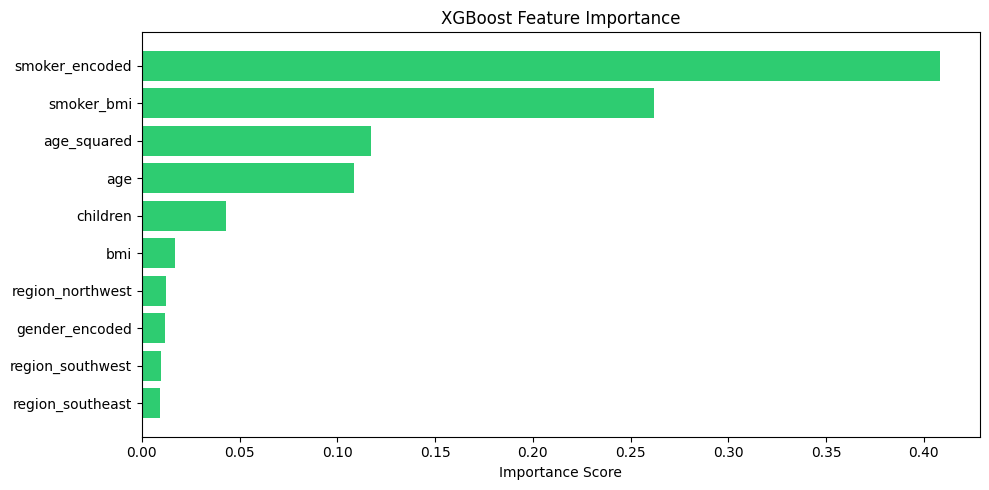

In [ ]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance (XGBoost):\n")
for _, row in importance_df.iterrows():
    print(f"  {row['Feature']:25s} : {row['Importance']:>12.4f}")

plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#2ecc71')
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Residual analysis (original `charges`)

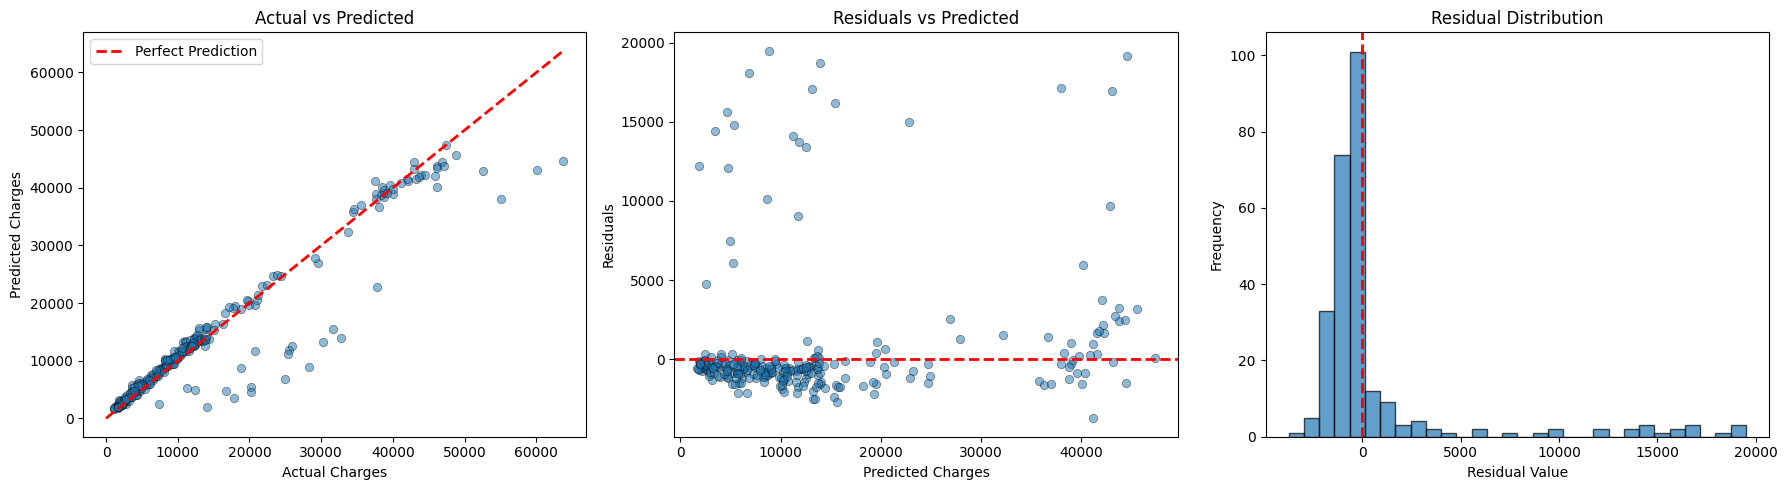

In [ ]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.5, edgecolors='black', linewidths=0.5)
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

axes[1].scatter(y_pred_test, residuals, alpha=0.5, edgecolors='black', linewidths=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted')

axes[2].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Residual Value')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

## 5b. Inspect Rows with the Largest Residuals and Export to CSV

The table below sorts the **test set** by `|y_actual - y_pred|` (original scale). The `residual_log` column compares the log-space target (`log1p`) against the model's raw output. The CSV file stores the **top N** rows for spreadsheet review.

In [ ]:
TOP_N = 25
OUT_CSV = "xgboost_log_reg_top_residuals_test.csv"

inspect_df = X_test.copy()
inspect_df.insert(0, "original_row_index", X_test.index.to_numpy())
inspect_df["y_actual"] = np.asarray(y_test)
inspect_df["y_pred"] = np.asarray(y_pred_test)
inspect_df["residual"] = inspect_df["y_actual"] - inspect_df["y_pred"]
inspect_df["abs_error"] = inspect_df["residual"].abs()
inspect_df["pct_abs_error"] = (
    inspect_df["abs_error"] / inspect_df["y_actual"].replace(0, np.nan) * 100
)

y_log_actual = np.log1p(inspect_df["y_actual"].to_numpy(dtype=float))
y_log_pred = model.predict(X_test)
inspect_df["residual_log"] = y_log_actual - y_log_pred
inspect_df["abs_error_log"] = np.abs(inspect_df["residual_log"])

inspect_sorted = inspect_df.sort_values("abs_error", ascending=False)
display(
    inspect_sorted.head(TOP_N).style.format(
        {
            "y_actual": "{:,.2f}",
            "y_pred": "{:,.2f}",
            "residual": "{:,.2f}",
            "abs_error": "{:,.2f}",
            "pct_abs_error": "{:.2f}",
            "residual_log": "{:.4f}",
            "abs_error_log": "{:.4f}",
        },
        na_rep="—",
    )
)

inspect_sorted.head(TOP_N).to_csv(OUT_CSV, index=False)
print(f"Exported top {TOP_N} rows by |residual| (original scale) to: {OUT_CSV}")

,original_row_index,age,age_squared,bmi,children,gender_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest,smoker_bmi,y_actual,y_pred,residual,abs_error,pct_abs_error,residual_log,abs_error_log
986,986,45,2025,27.645000,1,1,0,1.000000,0.000000,0.000000,0.000000,"28,340.19","8,835.42","19,504.77","19,504.77",68.82,1.1654,1.1654
543,543,54,2916,47.315000,0,1,1,0.000000,1.000000,0.000000,47.315000,"63,770.43","44,610.91","19,159.52","19,159.52",30.04,0.3573,0.3573
128,128,32,1024,17.765000,2,1,1,1.000000,0.000000,0.000000,17.765000,"32,734.19","13,987.02","18,747.16","18,747.16",57.27,0.8502,0.8502
636,636,35,1225,38.095000,2,1,0,0.000000,0.000000,0.000000,0.000000,"24,915.05","6,827.55","18,087.49","18,087.49",72.60,1.2944,1.2944
818,818,33,1089,35.530000,0,1,1,1.000000,0.000000,0.000000,35.530000,"55,135.40","38,001.25","17,134.15","17,134.15",31.08,0.3722,0.3722
115,115,60,3600,28.595000,0,0,0,0.000000,0.000000,0.000000,0.000000,"30,260.00","13,184.14","17,075.85","17,075.85",56.43,0.8308,0.8308
1229,1229,52,2704,34.485000,3,0,1,1.000000,0.000000,0.000000,34.485000,"60,021.40","43,051.66","16,969.73","16,969.73",28.27,0.3323,0.3323
573,573,62,3844,36.860000,1,1,0,0.000000,0.000000,0.000000,0.000000,"31,620.00","15,414.26","16,205.74","16,205.74",51.25,0.7185,0.7185
291,291,29,841,29.640000,1,0,0,0.000000,0.000000,0.000000,0.000000,"20,277.81","4,633.14","15,644.67","15,644.67",77.15,1.4761,1.4761
1302,1302,43,1849,27.800000,0,0,1,0.000000,0.000000,1.000000,27.800000,"37,829.72","22,830.06","14,999.66","14,999.66",39.65,0.5050,0.5050


Exported top 25 rows by |residual| (original scale) to: xgboost_log_reg_top_residuals_test.csv


This large residual is not a bug in the code and does not need to be removed from the data. It is the ceiling of the model's performance with currently available features. To significantly reduce this error, a richer feature domain is needed.

## 6. Training Monitoring (Learning Curve, RMSE in **log1p** Space)

This curve uses the same scale as early stopping. For business-facing interpretation, compare it with Section 3 metrics on the original scale.

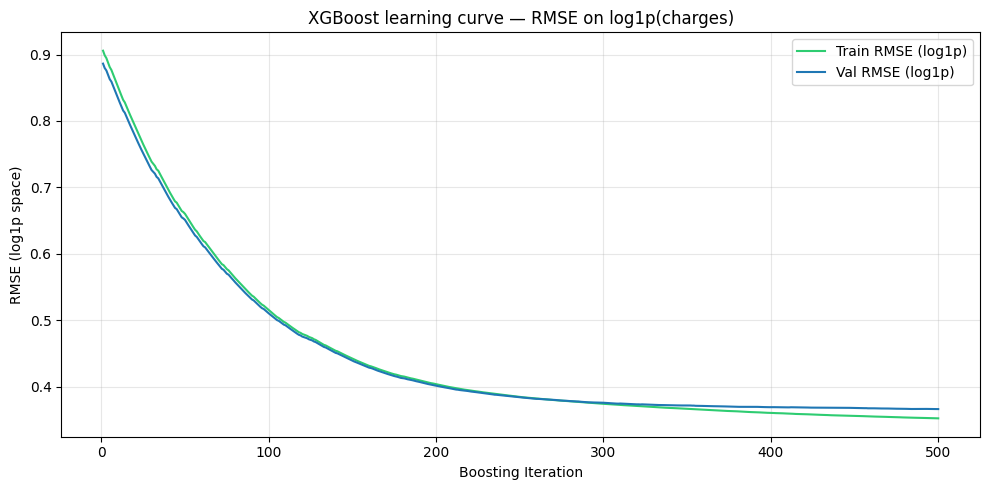

Best val RMSE (log1p): 0.3661 at round 500
Train-val RMSE gap   : 0.0139
There is no strong overfitting signal.


In [ ]:
train_rmse_curve = evals_result['validation_0']['rmse']
val_rmse_curve   = evals_result['validation_1']['rmse']

rounds = range(1, len(val_rmse_curve) + 1)

plt.figure(figsize=(10, 5))
plt.plot(rounds, train_rmse_curve, label='Train RMSE (log1p)', color='#2ecc71')
plt.plot(rounds, val_rmse_curve,   label='Val RMSE (log1p)',   color='#1f77b4')
plt.xlabel('Boosting Iteration')
plt.ylabel('RMSE (log1p space)')
plt.title('XGBoost learning curve — RMSE on log1p(charges)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_round       = int(np.argmin(val_rmse_curve)) + 1
best_val_rmse    = float(np.min(val_rmse_curve))
final_gap        = float(val_rmse_curve[-1] - train_rmse_curve[-1])

print(f'Best val RMSE (log1p): {best_val_rmse:.4f} at round {best_round}')
print(f'Train-val RMSE gap   : {final_gap:.4f}')
if final_gap > 0.08:
    print('Overfitting signal: val RMSE is much higher than train RMSE.')
else:
    print('There is no strong overfitting signal.')

## 7. Export Trained model to ML Model

In [ ]:
# # Export trained XGBoost model to ONNX
# # Output file: model.onnx
# # Note: this model predicts in log space (log1p(charges)).

# from pathlib import Path
# import json

# try:
#     from onnxmltools import convert_xgboost
#     from onnxmltools.convert.common.data_types import FloatTensorType
# except ImportError as e:
#     raise ImportError(
#         "onnxmltools is not installed. Install it first, e.g. `pip install onnxmltools onnx`."
#     ) from e

# if 'model' not in globals():
#     raise RuntimeError("`model` is not found. Run training cells first.")
# if 'feature_cols' not in globals():
#     raise RuntimeError("`feature_cols` is not found. Run feature preparation cells first.")

# n_features = len(feature_cols)
# initial_types = [('input', FloatTensorType([None, n_features]))]

# # onnxmltools expects XGBoost split names like f0, f1, ...
# # while our model was trained with column names (e.g., smoker_bmi).
# # Remap feature names on the booster before conversion.
# booster = model.get_booster()
# booster.feature_names = [f"f{i}" for i in range(n_features)]

# onnx_model = convert_xgboost(booster, initial_types=initial_types)

# out_path = Path('model.onnx')
# with open(out_path, 'wb') as f:
#     f.write(onnx_model.SerializeToString())

# metadata_path = Path('model.features.json')
# feature_metadata = {
#     "input_name": "input",
#     "training_feature_order": feature_cols,
#     "onnx_feature_alias": [f"f{i}" for i in range(n_features)],
#     "target_space": "log1p(charges)",
#     "postprocess": "expm1",
# }
# with open(metadata_path, 'w', encoding='utf-8') as f:
#     json.dump(feature_metadata, f, indent=2)

# print(f"Saved ONNX model to: {out_path.resolve()}")
# print(f"Saved feature metadata to: {metadata_path.resolve()}")
# print("Note: model output is in log space (log1p). Apply expm1 to recover charges scale.")
# print("Input order must follow feature_cols exactly.")

In [ ]:
import copy
import json
from pathlib import Path
import coremltools as ct

# --- direct convert XGBoost → Core ML / ml model ---
# deepcopy so that the original booster does not mutate
booster_export = copy.deepcopy(model.get_booster())

coreml_model = ct.converters.xgboost.convert(
    booster_export,
    feature_names=feature_cols,
    target='annual_premium_log',
    force_32bit_float=True,
    mode='regressor',
)

# --- Add metadata ---
coreml_model.short_description = (
    "Insurance annual premium predictor (XGBoost, log1p target). "
    "Apply expm1() to output to get actual premium value."
)

# --- Save .mlpackage ---
out_path = Path("model.mlmodel")
coreml_model.save(str(out_path))

# --- Save metadata feature ---
metadata_path = Path("model.features.json")
feature_metadata = {
    "training_feature_order": feature_cols,
    "target_space": "log1p(annual_premium)",
    "postprocess": "expm1",
}
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(feature_metadata, f, indent=2)

# --- Sanity check: original booster is not mutated ---
assert model.get_booster().feature_names == feature_cols, \
    "PERINGATAN: booster asli ikut termutasi!"

print(f"Saved Core ML model   : {out_path.resolve()}")
print(f"Saved feature metadata: {metadata_path.resolve()}")
print()
print("Feature order:")
for i, col in enumerate(feature_cols):
    print(f"  [{i:02d}] {col}")
print("\nSanity check passed: original booster is not mutated.")

Saved Core ML model   : /Users/ameliacitra/Documents/AI-ML/C1-Tabular/model.mlmodel
Saved feature metadata: /Users/ameliacitra/Documents/AI-ML/C1-Tabular/model.features.json

Feature order:
  [00] age
  [01] age_squared
  [02] bmi
  [03] children
  [04] gender_encoded
  [05] smoker_encoded
  [06] region_northwest
  [07] region_southeast
  [08] region_southwest
  [09] smoker_bmi

Sanity check passed: original booster is not mutated.
